# Analytic Gaussian OT Cost Comparison

Compares the transport cost computed by **LP (exact EMD)** and **BFM** against the
analytic optimal cost for two-marginal OT with single-Gaussian marginals in 1D, 2D, and 3D.

For a single Gaussian pair $(\mu, \nu)$ the closed-form Monge map is an affine map
$T(x) = Ax + b$; we evaluate its discretized displacement cost
$\sum_i \|x_i - T(x_i)\|^2 \mu_i$ directly from the analytic solution returned by
`generate_with_analytic_solution()` — no extra Bures formula needed.

> **Note:** all three costs live on the same discretized, truncated measures so they
> should be directly comparable. Residual differences reflect numerical precision,
> grid resolution, and domain-truncation effects.

In [1]:
import sys, os

os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'platform'
sys.path.insert(0, os.path.abspath('..'))

import jax
from jax import config
config.update('jax_enable_x64', True)

# Use first GPU if available, otherwise CPU
try:
    _gpus = jax.devices('gpu')
    _device = _gpus[0]
    print(f'GPU detected: {_device}. Using first GPU.')
except RuntimeError:
    _device = jax.devices('cpu')[0]
    print('No GPU detected. Using CPU.')

jax.config.update('jax_default_device', _device)

import time
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from uot.problems.generators import GaussianMixtureGenerator
from uot.utils.costs import cost_euclid_squared
from uot.data.measure import PointCloudMeasure
from uot.solvers.back_and_forth import BackNForthSqEuclideanSolver
from uot.solvers.back_and_forth.pushforward import adaptive_pushforward_nd
from uot.solvers.linear_programming import LinearProgrammingTwoMarginalSolver
from uot.solvers.sinkhorn import SinkhornTwoMarginalSolver

import logging
logging.getLogger('uot').setLevel(logging.WARNING)

No GPU detected. Using CPU.


In [2]:
# ── publication-ready matplotlib style (minimal) ──────────────────────────────
def set_pub_style():
    plt.rcParams.update({
        'font.size': 11,
        'axes.titlesize': 11,
        'axes.labelsize': 11,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'figure.dpi': 150,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
    })

set_pub_style()

## Configuration

Edit the cells below to change grid sizes, number of problems, BFM parameters, etc.

In [3]:
# ── per-dimension grid sizes ───────────────────────────────────────────────────
# Keep 3D small: the dense LP cost matrix is (n^3 × n^3).
GRID_SIZES = {1: 512, 2: 64, 3: 32}
# GRID_SIZES = {1: 512, 2: 128, 3: 32}

BORDERS   = (0.0, 1.0)
N_PROBLEMS = 30       # Gaussian pairs per dimension
SEED      = 45

# BFM solver hyperparameters (applied to all dimensions)
BFM_PARAMS = dict(
    maxiter=800,
    tol=1e-4,
    stepsize=1.0,
    error_metric='h1_psi_relative',
    stepsize_lower_bound=0.01,
)

# Sinkhorn hyperparameters
# Note: Sinkhorn solves regularised OT, so costs are biased by reg.
# Dense kernel — only feasible for 1D at GRID_SIZES above.
SINKHORN_PARAMS = dict(
    reg=1e-3,
    maxiter=5_000,
    tol=1e-6,
)

# Distribution registry — add entries here to test other distributions.
# Each factory receives (dim, n_points, seed, n_problems) and must return a
# GaussianMixtureGenerator with num_components=1 (analytic solution requires it).
def _make_gaussian_gen(dim, n_points, seed, n_problems):
    return GaussianMixtureGenerator(
        name=f'gaussian_1c_{dim}d',
        dim=dim,
        num_components=1,
        n_points=n_points,
        num_datasets=n_problems,
        borders=BORDERS,
        cost_fn=cost_euclid_squared,
        use_jax=False,
        seed=seed,
        measure_mode='grid',
        cell_discretization='cell-centered',
    )

DISTRIBUTIONS = {
    'gaussian': _make_gaussian_gen,
    # 'my_other_dist': _make_other_gen,  # add here
}

## Helper: analytic displacement cost

The analytic solution provides the physical Monge map `T(x)` on the grid.
We compute the same displacement cost that the BFM solver uses internally:
$$\text{cost} = \sum_i \|x_i - T(x_i)\|^2 \mu_i$$

In [4]:
def analytic_displacement_cost(analytic_sol, mu_nd, axes):
    """Displacement cost of the analytic map on the discretized mu grid."""
    X = jnp.stack(jnp.meshgrid(*axes, indexing='ij'), axis=-1)  # (*shape, d)
    T = jnp.asarray(analytic_sol['monge_map_physical'])           # (*shape, d)
    diff = X - T
    return float(jnp.sum(jnp.sum(diff * diff, axis=-1) * mu_nd))


def _monge_map_index_to_physical(monge_map, axes):
    arr = jnp.asarray(monge_map)
    spatial_shape = tuple(len(ax) for ax in axes)
    d = len(spatial_shape)
    if arr.ndim == len(spatial_shape):
        arr = arr[..., None]
    if arr.shape[0] == d and arr.ndim == len(spatial_shape) + 1:
        arr = jnp.moveaxis(arr, 0, -1)
    elif arr.shape[-1] != d:
        arr = arr.reshape(spatial_shape + (d,))
    spacings = jnp.array([float(ax[1] - ax[0]) if ax.shape[0] > 1 else 1.0 for ax in axes], dtype=arr.dtype)
    origins  = jnp.array([float(ax[0]) for ax in axes], dtype=arr.dtype)
    reshape  = (1,) * len(spatial_shape) + (d,)
    return origins.reshape(reshape) + arr * spacings.reshape(reshape)

## Run benchmark

In [5]:
def _compress_measure(measure, rel_tol=1e-10):
    """Drop grid points whose weight is below rel_tol * max_weight, renormalise."""
    X, w = measure.as_point_cloud()
    X, w = np.asarray(X), np.asarray(w)
    mask = w > rel_tol * w.max()
    w_c = w[mask]
    w_c = w_c / w_c.sum()
    return PointCloudMeasure(jnp.asarray(X[mask]), jnp.asarray(w_c))


lp_solver       = LinearProgrammingTwoMarginalSolver()
bfm_solver      = BackNForthSqEuclideanSolver(pushforward_fn=adaptive_pushforward_nd)
sinkhorn_solver = SinkhornTwoMarginalSolver()

records = []

for dim in (1, 2, 3):
    n_points = GRID_SIZES[dim]
    print(f'\n── dim={dim}  grid={n_points}^{dim}  n_problems={N_PROBLEMS} ──')

    for dist_name, factory in DISTRIBUTIONS.items():
        gen = factory(dim, n_points, SEED, N_PROBLEMS)

        for prob_idx, (problem, analytic) in enumerate(gen.generate_with_analytic_solution()):
            mu_measure, nu_measure = problem.get_marginals()
            axes_mu, mu_nd = mu_measure.as_grid(backend='jax', dtype=jnp.float64)
            _,        nu_nd = nu_measure.as_grid(backend='jax', dtype=jnp.float64)

            # ── analytic cost (displacement cost of the closed-form affine map) ──
            cost_analytic = analytic_displacement_cost(analytic, mu_nd, axes_mu)

            # ── compressed point-cloud measures for LP and Sinkhorn ───────────
            # BFM needs the full grid; LP/Sinkhorn only need points with
            # non-negligible mass, which keeps the cost matrix small.
            mu_pc = _compress_measure(mu_measure)
            nu_pc = _compress_measure(nu_measure)
            X_mu, w_mu = mu_pc.as_point_cloud()
            X_nu, w_nu = nu_pc.as_point_cloud()
            C_pc = cost_euclid_squared(X_mu, X_nu)

            # ── LP (exact EMD) cost ────────────────────────────────────────────
            t0 = time.perf_counter()
            lp_out = lp_solver.solve(
                marginals=[mu_pc, nu_pc],
                costs=[C_pc],
                numItermax=1_000_000,
            )
            t_lp = time.perf_counter() - t0
            cost_lp = float(lp_out['cost'])

            # ── BFM cost ───────────────────────────────────────────────────────
            t0 = time.perf_counter()
            bfm_out = bfm_solver.solve(
                marginals=[mu_measure, nu_measure],
                costs=[],
                **BFM_PARAMS,
            )
            t_bfm = time.perf_counter() - t0
            cost_bfm = float(bfm_out['cost'])

            # ── Sinkhorn cost ──────────────────────────────────────────────────
            t0 = time.perf_counter()
            sk_out = sinkhorn_solver.solve(
                marginals=[mu_pc, nu_pc],
                costs=[C_pc],
                **SINKHORN_PARAMS,
            )
            t_sk = time.perf_counter() - t0
            cost_sk = float(sk_out['cost'])

            # Signed relative error: positive = overestimate, negative = underestimate
            denom = abs(cost_analytic) + 1e-30
            signed_err_lp  = (cost_lp  - cost_analytic) / denom
            signed_err_bfm = (cost_bfm - cost_analytic) / denom
            signed_err_sk  = (cost_sk  - cost_analytic) / denom

            records.append(dict(
                distribution=dist_name,
                dim=dim,
                problem_index=prob_idx,
                cost_analytic=cost_analytic,
                cost_lp=cost_lp,
                cost_bfm=cost_bfm,
                cost_sk=cost_sk,
                signed_err_lp=signed_err_lp,
                signed_err_bfm=signed_err_bfm,
                signed_err_sk=signed_err_sk,
                t_lp=t_lp,
                t_bfm=t_bfm,
                t_sk=t_sk,
                n_pts_pc=int(X_mu.shape[0]),
                bfm_iters=int(bfm_out['iterations']),
                sk_iters=int(sk_out['iterations']),
            ))

            if (prob_idx + 1) % 5 == 0:
                print(f'  [{dist_name}] problem {prob_idx+1}/{N_PROBLEMS}  '
                      f'pts={X_mu.shape[0]}  '
                      f'analytic={cost_analytic:.4e}  lp={cost_lp:.4e}  '
                      f'bfm={cost_bfm:.4e}  sinkhorn={cost_sk:.4e}')

df = pd.DataFrame(records)
print('\nDone. Total rows:', len(df))
df.head()


── dim=1  grid=512^1  n_problems=30 ──
  [gaussian] problem 5/30  pts=337  analytic=1.0757e-01  lp=1.0757e-01  bfm=1.0569e-01  sinkhorn=7.0351e-02
  [gaussian] problem 10/30  pts=381  analytic=1.3468e-01  lp=1.3450e-01  bfm=1.3448e-01  sinkhorn=4.5470e-02
  [gaussian] problem 15/30  pts=292  analytic=1.7361e-03  lp=1.7368e-03  bfm=1.7345e-03  sinkhorn=2.1978e-03
  [gaussian] problem 20/30  pts=240  analytic=2.0128e-02  lp=2.0128e-02  bfm=1.9791e-02  sinkhorn=2.0521e-02
  [gaussian] problem 25/30  pts=444  analytic=8.5071e-02  lp=8.4877e-02  bfm=8.4356e-02  sinkhorn=5.0343e-02
  [gaussian] problem 30/30  pts=226  analytic=8.3297e-03  lp=8.2869e-03  bfm=8.2187e-03  sinkhorn=8.5267e-03

── dim=2  grid=64^2  n_problems=30 ──
  [gaussian] problem 5/30  pts=1199  analytic=1.0125e-01  lp=1.0137e-01  bfm=1.0065e-01  sinkhorn=6.4083e-02
  [gaussian] problem 10/30  pts=808  analytic=2.2761e-01  lp=2.2759e-01  bfm=2.2767e-01  sinkhorn=2.2242e-02
  [gaussian] problem 15/30  pts=1284  analytic=1.1

,distribution,dim,problem_index,cost_analytic,cost_lp,cost_bfm,cost_sk,signed_err_lp,signed_err_bfm,signed_err_sk,t_lp,t_bfm,t_sk,n_pts_pc,bfm_iters,sk_iters
0,gaussian,1,0,0.020490,0.020488,0.019806,0.020671,-0.000096,-0.033396,0.008810,0.014658,1.301271,0.136158,498,76,5000
1,gaussian,1,1,0.006671,0.006672,0.006476,0.007112,0.000107,-0.029286,0.066156,0.007602,0.672597,0.145519,341,800,5000
2,gaussian,1,2,0.023590,0.023582,0.023554,0.022434,-0.000322,-0.001520,-0.048982,0.017806,0.223361,0.103868,512,165,5000
3,gaussian,1,3,0.093623,0.093623,0.086322,0.079830,0.000008,-0.077974,-0.147323,0.002839,0.139090,0.128266,234,41,5000
4,gaussian,1,4,0.107573,0.107574,0.105688,0.070351,0.000006,-0.017523,-0.346012,0.005149,0.137916,0.127916,337,47,5000


## Summary statistics

In [6]:
summary = (
    df.groupby(['distribution', 'dim'])[['signed_err_lp', 'signed_err_bfm', 'signed_err_sk']]
    .agg(['mean', 'median', 'std'])
    .round(6)
)
print(summary.to_string())
print('\n(positive = overestimate, negative = underestimate)')

                 signed_err_lp                     signed_err_bfm                     signed_err_sk                    
                          mean    median       std           mean    median       std          mean    median       std
distribution dim                                                                                                       
gaussian     1       -0.001104  0.000013  0.002987      -0.014525 -0.011801  0.015767      0.068890  0.011196  0.567186
             2        0.016795  0.000505  0.088588       0.002461 -0.011532  0.095370     -0.479383 -0.478033  0.385038
             3        0.002922  0.003497  0.007760      -0.055255 -0.027191  0.065519     -0.508178 -0.478842  0.364846

(positive = overestimate, negative = underestimate)


## Figure — absolute cost and relative error

<>:69: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:69: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
/var/folders/zt/h5ncncv1043cdpswcj8nysgm0000gn/T/ipykernel_58539/1705766359.py:69: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  ax.set_ylabel('Signed relative error  $(c_{solver} - c_{analytic})\,/\,c_{analytic}$')


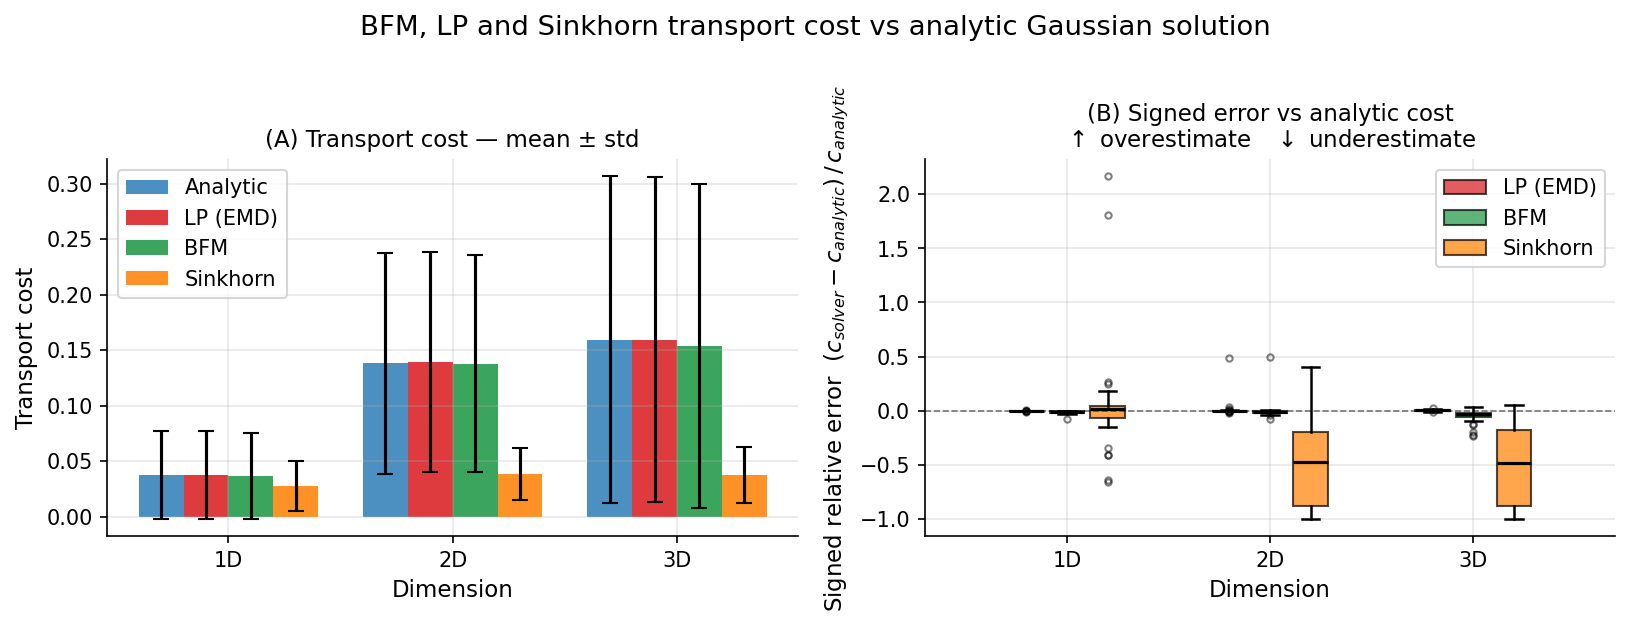

Saved to figures/gaussian_analytic_cost_comparison.{png,pdf}


In [7]:
dims = sorted(df['dim'].unique())
x = np.arange(len(dims))
width = 0.2
colors = {'analytic': '#2C7BB6', 'lp': '#D7191C', 'bfm': '#1A9641', 'sk': '#FF7F00'}

fig, axes_fig = plt.subplots(1, 2, figsize=(11, 4))

# ── Panel A: absolute costs (mean ± std) ──────────────────────────────────────
ax = axes_fig[0]
offsets = [-1.5, -0.5, 0.5, 1.5]
for i, (label, col) in enumerate([('Analytic',  'cost_analytic'),
                                   ('LP (EMD)',  'cost_lp'),
                                   ('BFM',       'cost_bfm'),
                                   ('Sinkhorn',  'cost_sk')]):
    means = [df[df['dim'] == d][col].mean() for d in dims]
    stds  = [df[df['dim'] == d][col].std()  for d in dims]
    ax.bar(x + offsets[i] * width, means, width,
           yerr=stds, capsize=4, label=label,
           color=list(colors.values())[i], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'{d}D' for d in dims])
ax.set_xlabel('Dimension')
ax.set_ylabel('Transport cost')
ax.set_title('(A) Transport cost — mean ± std')
ax.legend()

# ── Panel B: signed relative error (box per dim) ─────────────────────────────
ax = axes_fig[1]
positions_lp  = x - width
positions_bfm = x
positions_sk  = x + width

bp_lp = ax.boxplot(
    [df[df['dim'] == d]['signed_err_lp'].values for d in dims],
    positions=positions_lp, widths=width * 0.85,
    patch_artist=True,
    boxprops=dict(facecolor=colors['lp'], alpha=0.7),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5),
)
bp_bfm = ax.boxplot(
    [df[df['dim'] == d]['signed_err_bfm'].values for d in dims],
    positions=positions_bfm, widths=width * 0.85,
    patch_artist=True,
    boxprops=dict(facecolor=colors['bfm'], alpha=0.7),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5),
)
bp_sk = ax.boxplot(
    [df[df['dim'] == d]['signed_err_sk'].values for d in dims],
    positions=positions_sk, widths=width * 0.85,
    patch_artist=True,
    boxprops=dict(facecolor=colors['sk'], alpha=0.7),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5),
)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f'{d}D' for d in dims])
ax.set_xlabel('Dimension')
ax.set_ylabel('Signed relative error  $(c_{solver} - c_{analytic})\,/\,c_{analytic}$')
ax.set_title('(B) Signed error vs analytic cost\n'
             r'$\uparrow$ overestimate   $\downarrow$ underestimate')
ax.legend([bp_lp['boxes'][0], bp_bfm['boxes'][0], bp_sk['boxes'][0]],
          ['LP (EMD)', 'BFM', 'Sinkhorn'])

fig.suptitle('BFM, LP and Sinkhorn transport cost vs analytic Gaussian solution', y=1.02)
fig.tight_layout()

os.makedirs('figures', exist_ok=True)
fig.savefig('figures/gaussian_analytic_cost_comparison.png', bbox_inches='tight')
fig.savefig('figures/gaussian_analytic_cost_comparison.pdf', bbox_inches='tight')
plt.show()
print('Saved to figures/gaussian_analytic_cost_comparison.{png,pdf}')

<>:48: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
<>:48: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
/var/folders/zt/h5ncncv1043cdpswcj8nysgm0000gn/T/ipykernel_58539/1627429920.py:48: SyntaxWarning: "\," is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\,"? A raw string is also an option.
  ax.set_ylabel('Signed relative error  $(c_{solver} - c_{analytic})\,/\,c_{analytic}$')


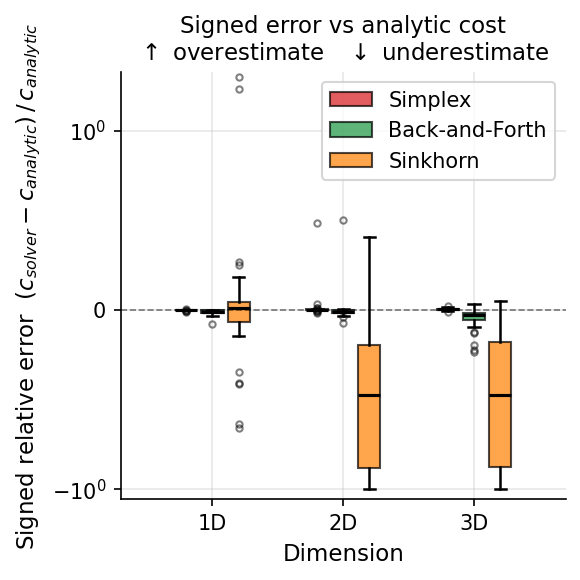

In [11]:
dims = sorted(df['dim'].unique())
x = np.arange(len(dims))
width = 0.2
colors = {'analytic': '#2C7BB6', 'lp': '#D7191C', 'bfm': '#1A9641', 'sk': '#FF7F00'}

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

positions_lp  = x - width
positions_bfm = x
positions_sk  = x + width

bp_lp = ax.boxplot(
    [df[df['dim'] == d]['signed_err_lp'].values for d in dims],
    positions=positions_lp, widths=width * 0.85,
    patch_artist=True,
    boxprops=dict(facecolor=colors['lp'], alpha=0.7),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5),
)
bp_bfm = ax.boxplot(
    [df[df['dim'] == d]['signed_err_bfm'].values for d in dims],
    positions=positions_bfm, widths=width * 0.85,
    patch_artist=True,
    boxprops=dict(facecolor=colors['bfm'], alpha=0.7),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5),
)
bp_sk = ax.boxplot(
    [df[df['dim'] == d]['signed_err_sk'].values for d in dims],
    positions=positions_sk, widths=width * 0.85,
    patch_artist=True,
    boxprops=dict(facecolor=colors['sk'], alpha=0.7),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=3, alpha=0.5),
)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_yscale('symlog', linthresh=1.0)
ax.set_xticklabels([f'{d}D' for d in dims])
ax.set_xlabel('Dimension')
ax.set_ylabel('Signed relative error  $(c_{solver} - c_{analytic})\,/\,c_{analytic}$')
ax.set_title('Signed error vs analytic cost\n'
             r'$\uparrow$ overestimate   $\downarrow$ underestimate')
ax.legend([bp_lp['boxes'][0], bp_bfm['boxes'][0], bp_sk['boxes'][0]],
          ['Simplex', 'Back-and-Forth', 'Sinkhorn'])

fig.tight_layout()